In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

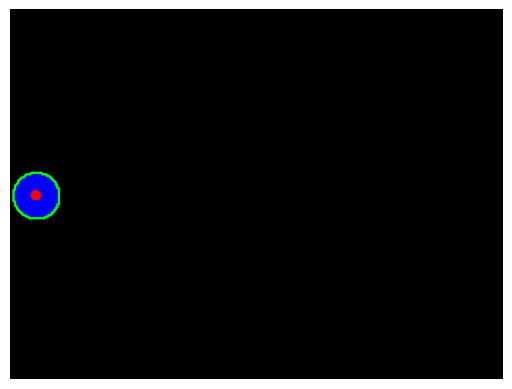

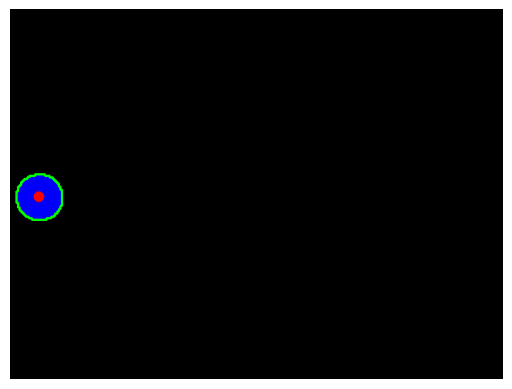

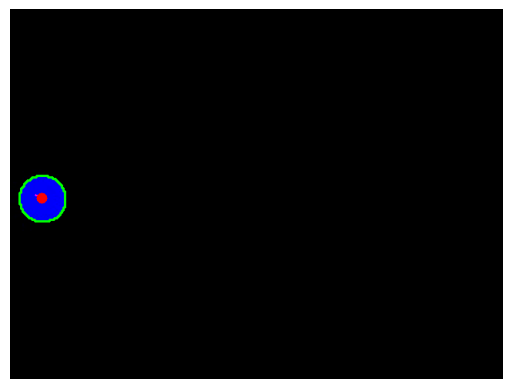

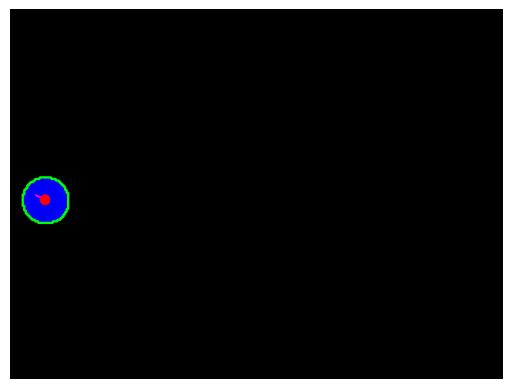

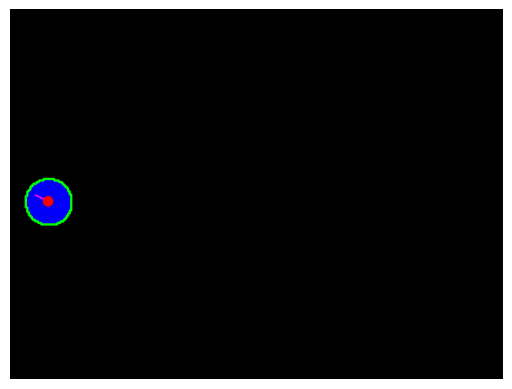

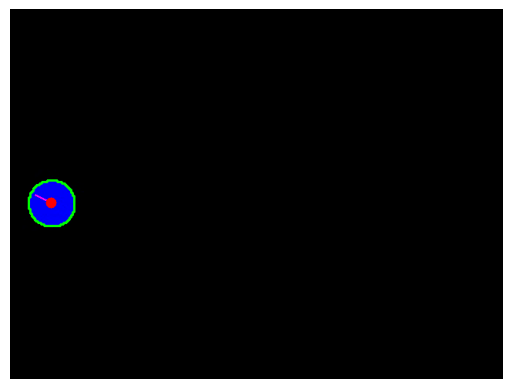

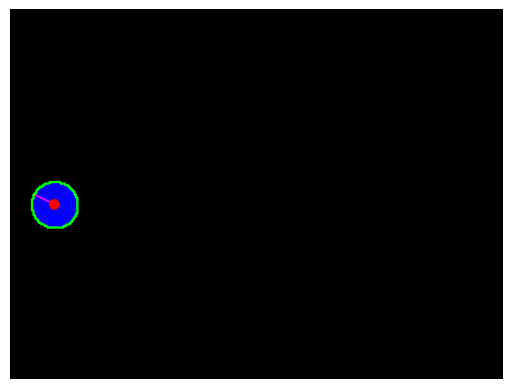

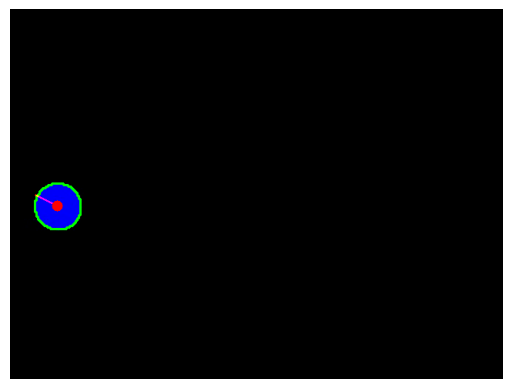

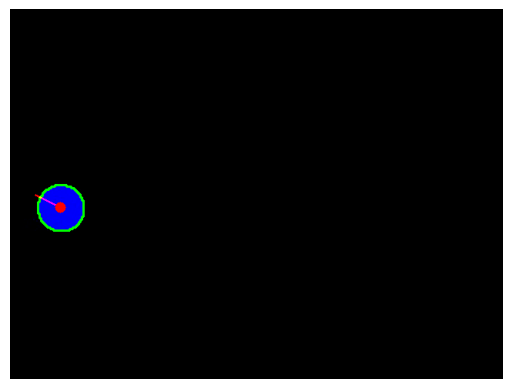

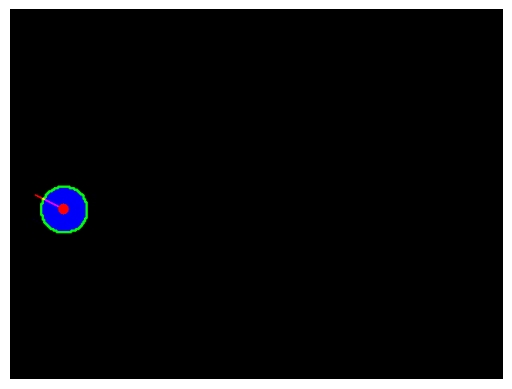

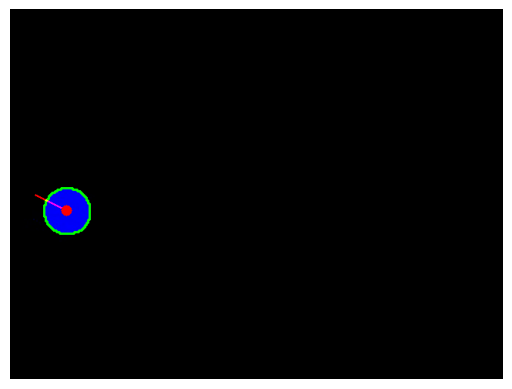

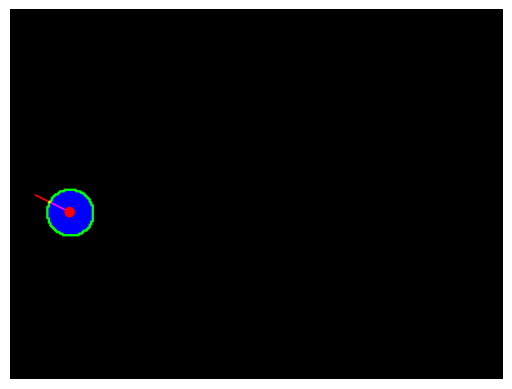

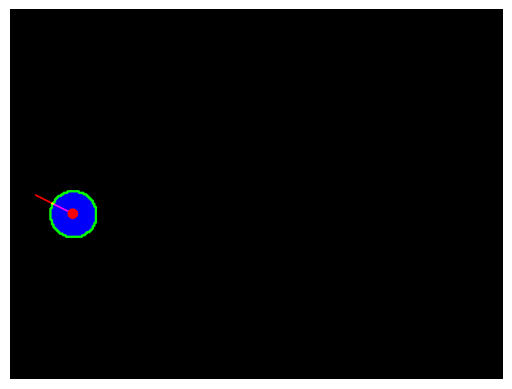

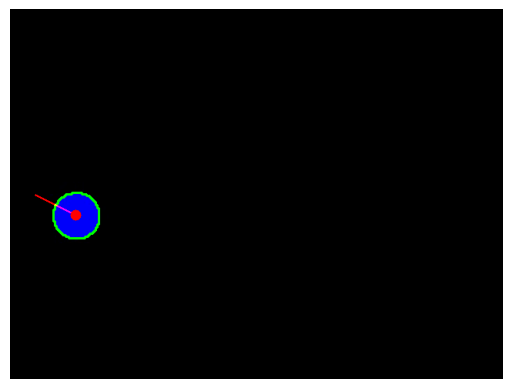

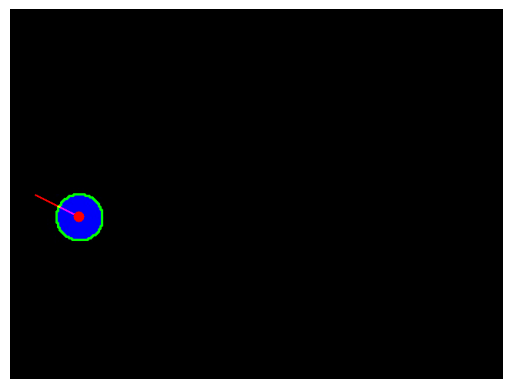

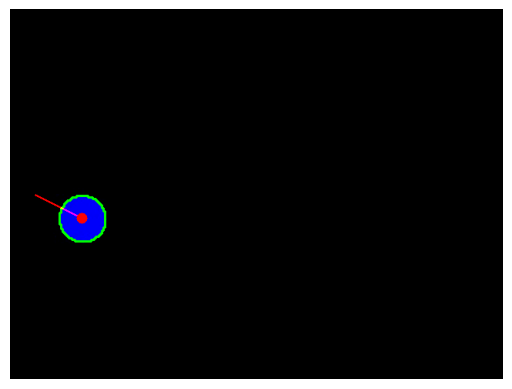

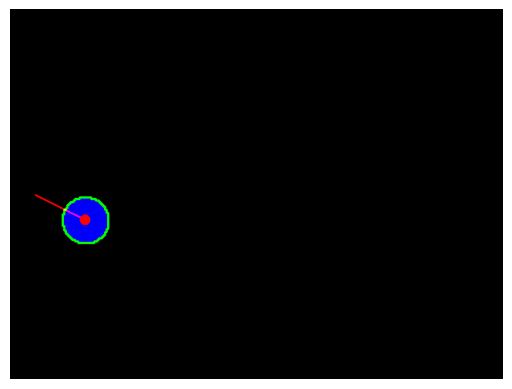

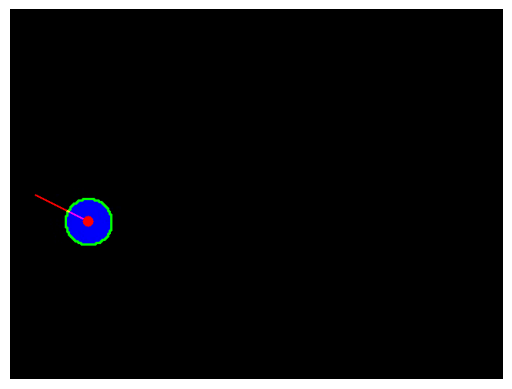

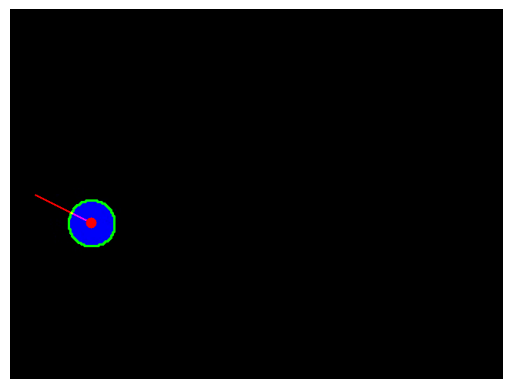

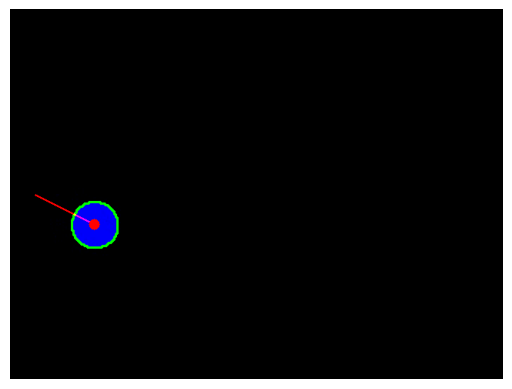

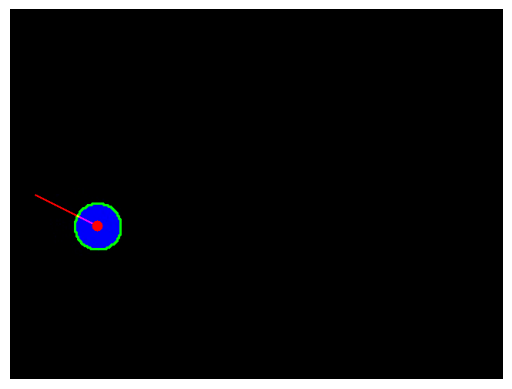

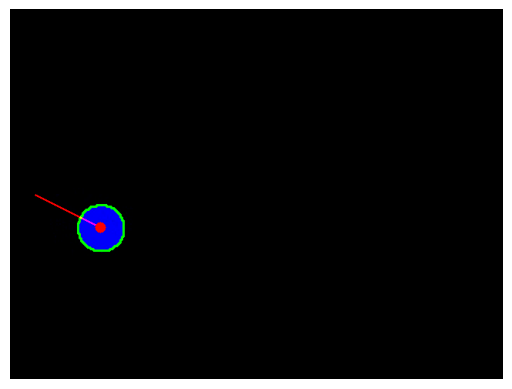

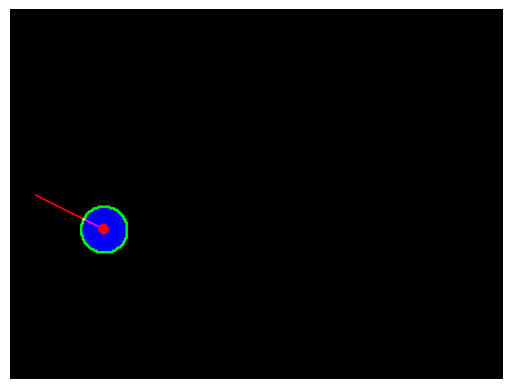

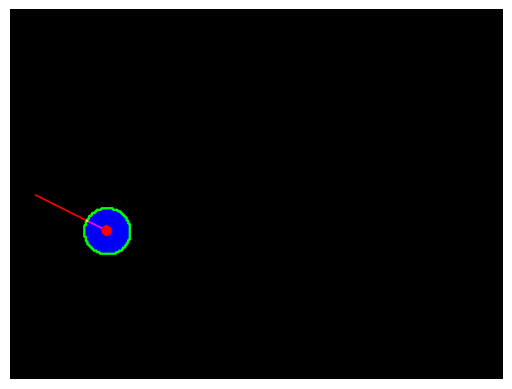

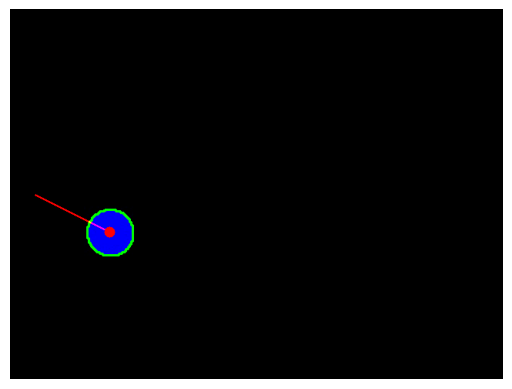

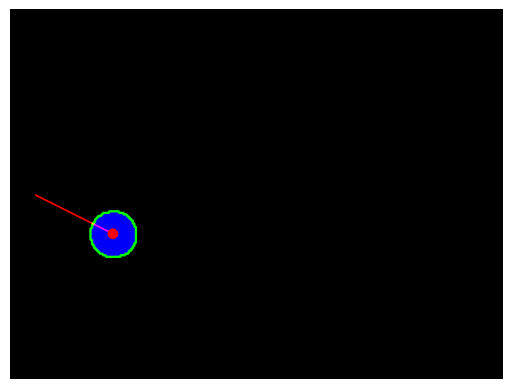

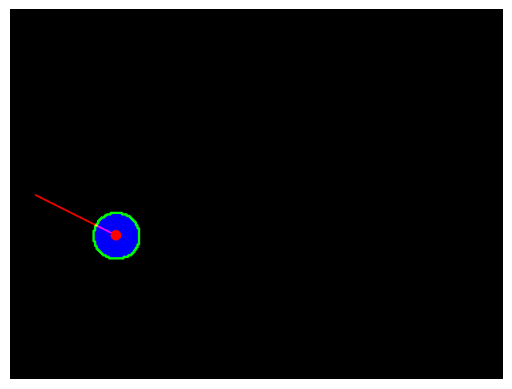

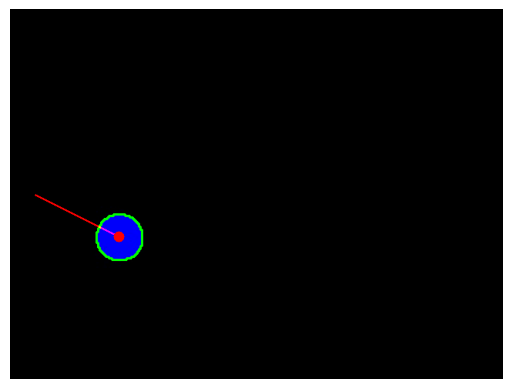

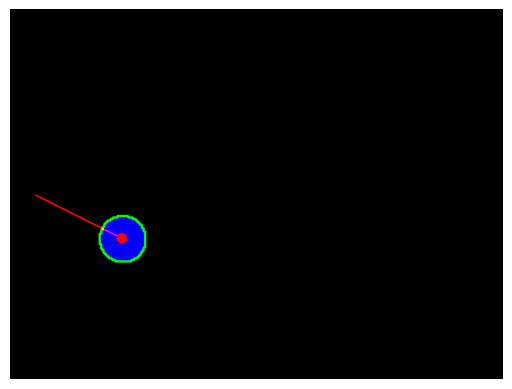

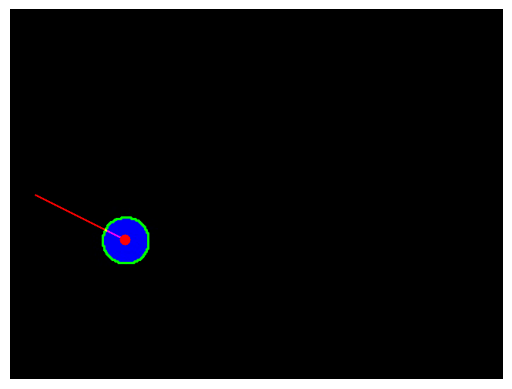

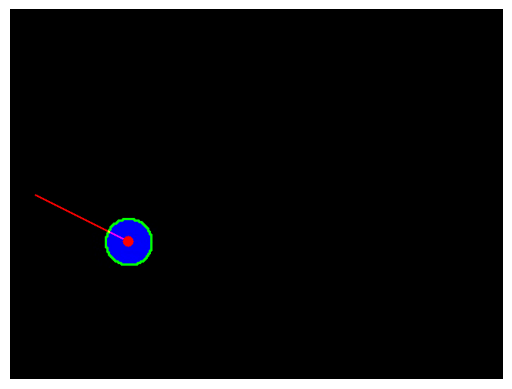

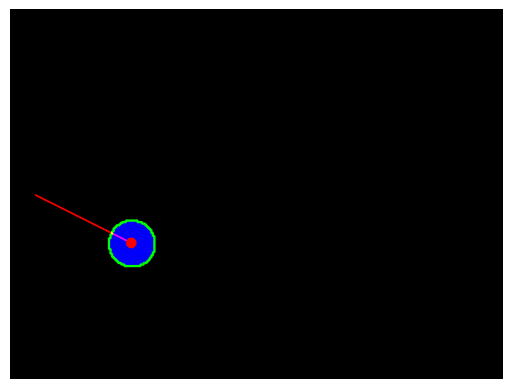

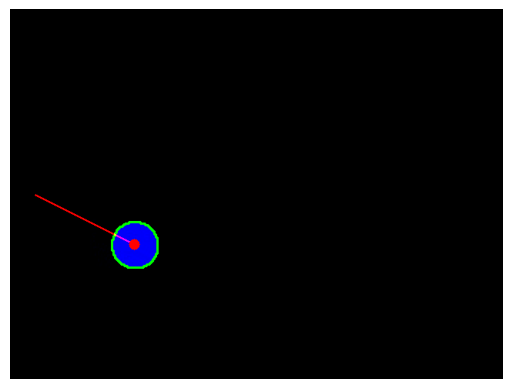

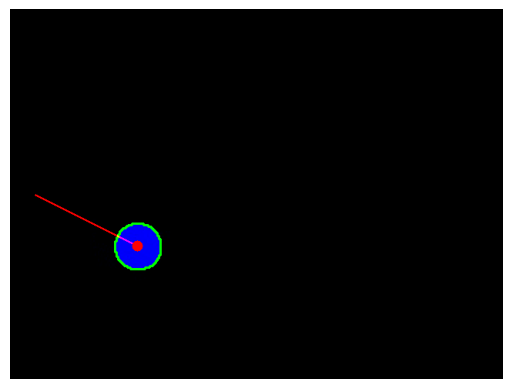

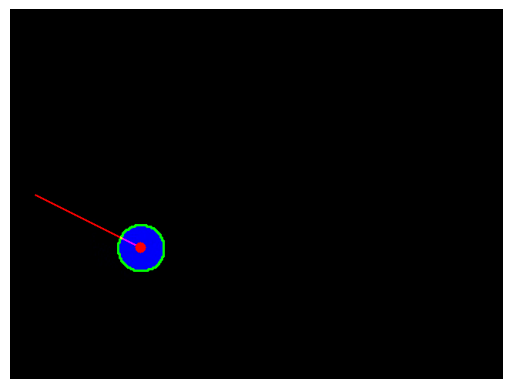

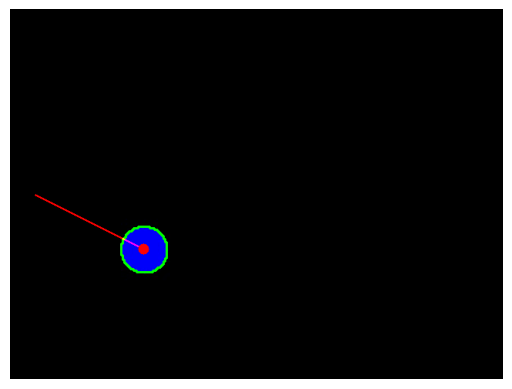

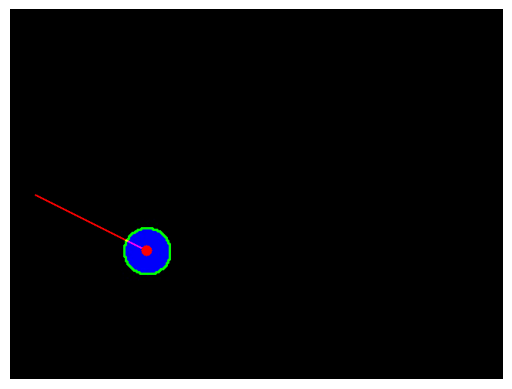

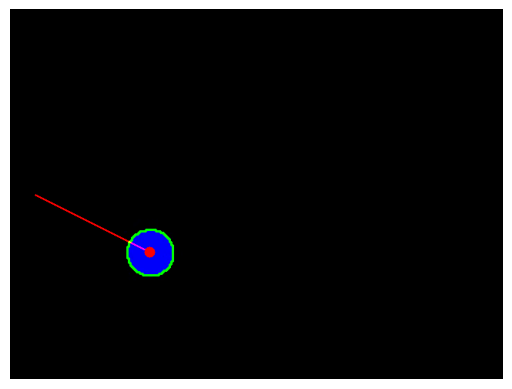

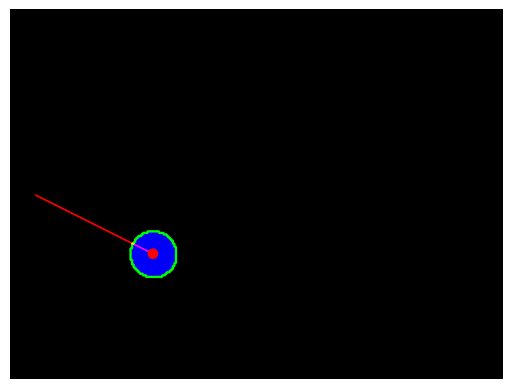

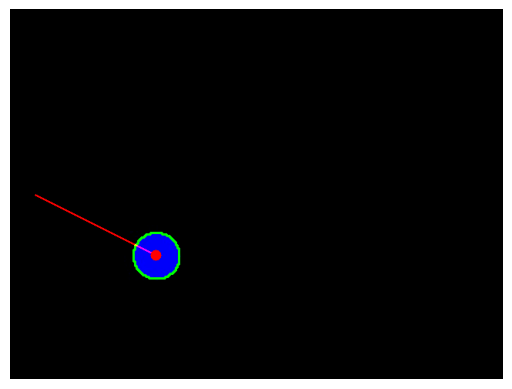

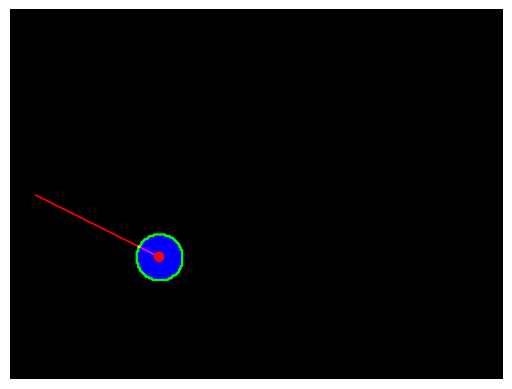

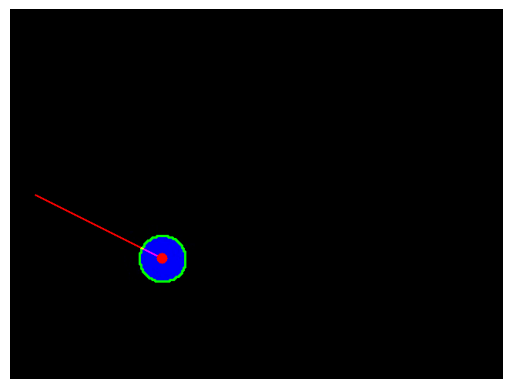

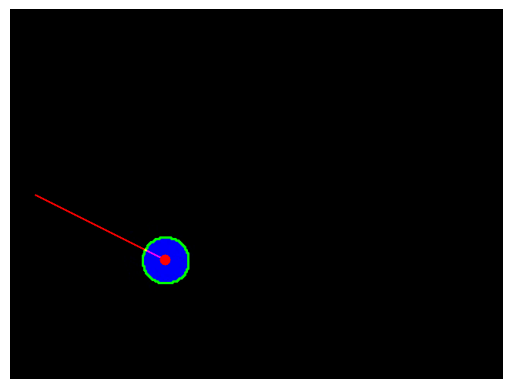

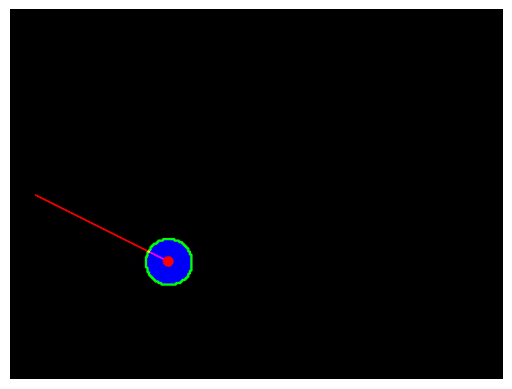

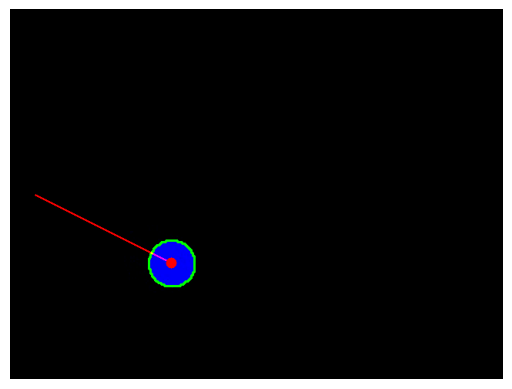

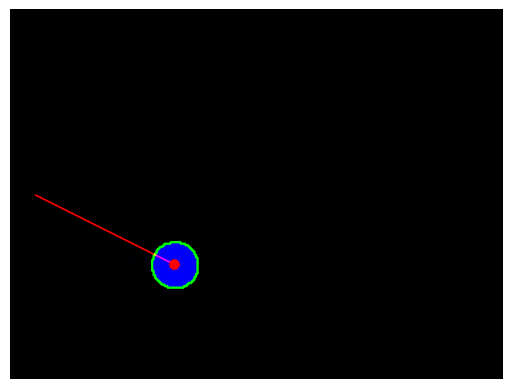

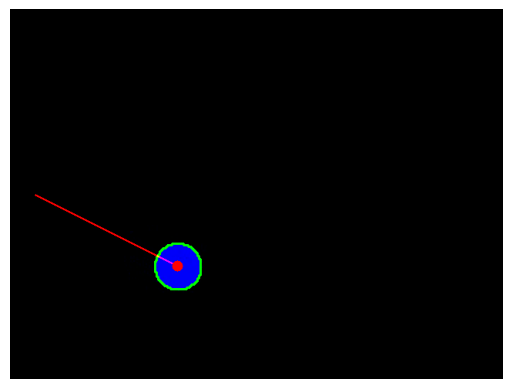

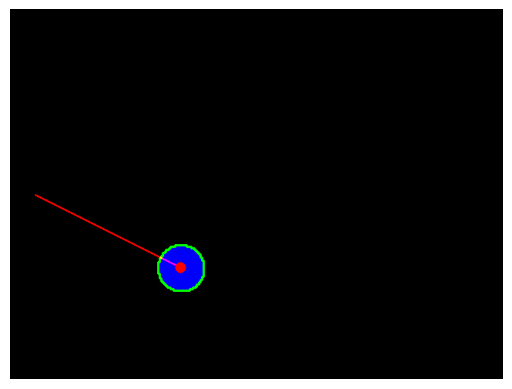

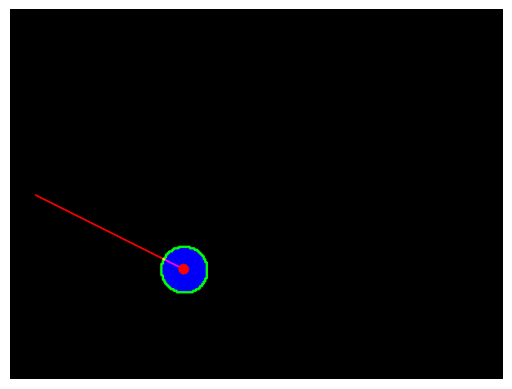

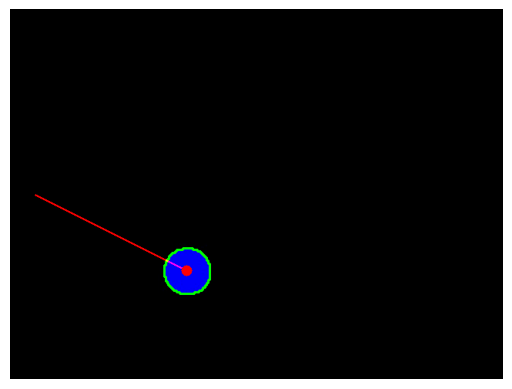

In [12]:
# Open video file
cap = cv.VideoCapture(
    '/content/drive/MyDrive/Colab Notebooks/videos/blue_ball.mp4'
)

# Read first frame to initialize trajectory image
ret, frame = cap.read()

if not ret:
    print("Error reading video file")
    exit()

# Image used to store trajectory history
trajectory = np.zeros_like(frame)

# HSV range for blue color
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

# Morphological kernel
kernel = np.ones((5, 5), np.uint8)

# List for storing object centers
points = []

for i in range(50):

    # Read next frame
    ret, frame = cap.read()

    if not ret:
        break

    # Convert frame to HSV color space
    hsv_frame = cv.cvtColor(
        frame,
        cv.COLOR_BGR2HSV
    )

    # Extract blue pixels
    mask = cv.inRange(
        hsv_frame,
        lower_blue,
        upper_blue
    )

    # Remove small white noise
    opening = cv.morphologyEx(
        mask,
        cv.MORPH_OPEN,
        kernel
    )

    # Fill small holes inside object
    closing = cv.morphologyEx(
        opening,
        cv.MORPH_CLOSE,
        kernel
    )

    # Detect object contours
    contours, _ = cv.findContours(
        closing,
        cv.RETR_EXTERNAL,
        cv.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        print("No contours found")
        continue

    # Select largest contour
    largest_contour = max(
        contours,
        key=cv.contourArea
    )

    # Compute contour moments
    M = cv.moments(
        largest_contour
    )

    if M["m00"] == 0:
        continue

    # Compute centroid coordinates
    cx = int(
        M["m10"] / M["m00"]
    )

    cy = int(
        M["m01"] / M["m00"]
    )

    # Store centroid in trajectory history
    points.append(
        (cx, cy)
    )

    # Draw detected contour
    cv.drawContours(
        frame,
        [largest_contour],
        -1,
        (0, 255, 0),
        2
    )

    # Draw current centroid
    cv.circle(
        frame,
        (cx, cy),
        7,
        (0, 0, 255),
        -1
    )

    # Draw only newest trajectory segment
    if len(points) > 1:

        cv.line(
            trajectory,
            points[-2],
            points[-1],
            (0, 0, 255),
            2
        )

    # Overlay trajectory on current frame
    cv.add(
        frame,
        trajectory,
        frame
    )

    # Display result
    imshow(image=frame)

# Release resources
cap.release()
cv.destroyAllWindows()